# L3.4 — Regularization (L2, Dropout, Early Stopping)

Hands-on notebook for the lesson [`3-4-regularization.mdx`](../../llm-quest-theory/level-3/3-4-regularization.mdx).

> **Learning objectives**
> - Overfit a small dataset on purpose, then fight back with three classic remedies.
> - Read train vs validation loss curves and tell overfitting from underfitting at a glance.
> - Wire `weight_decay`, `nn.Dropout`, and early stopping into the same training loop and compare on a held-out set.

## Connection to the theory
Covers **§1–§8** of the source `.mdx`. L1 and data augmentation are mentioned but not central here — we concentrate on the three tools you will reach for 95% of the time.

In [1]:
# ---- Setup ----
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from sklearn.datasets import make_moons

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. A small, noisy dataset — primed to overfit
Only 80 training samples, generous noise, and an intentionally oversized MLP.

In [2]:
X_np, y_np = make_moons(n_samples=260, noise=0.35, random_state=SEED)
# Split: 80 train, 60 val, 120 test — small train on purpose.
rng = np.random.default_rng(SEED)
perm = rng.permutation(len(X_np))
tr, va, te = perm[:80], perm[80:140], perm[140:]

X_tr = torch.tensor(X_np[tr], dtype=torch.float32)
y_tr = torch.tensor(y_np[tr], dtype=torch.float32)
X_va = torch.tensor(X_np[va], dtype=torch.float32)
y_va = torch.tensor(y_np[va], dtype=torch.float32)
X_te = torch.tensor(X_np[te], dtype=torch.float32)
y_te = torch.tensor(y_np[te], dtype=torch.float32)
print(f"train={len(X_tr)}, val={len(X_va)}, test={len(X_te)}")

train=80, val=60, test=120


## 2. Shared training loop
One function, parameterised by `weight_decay`, `dropout`, and an `early_stopping` flag.

In [3]:
class BigMLP(nn.Module):
    def __init__(self, hidden=128, dropout=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, 1),
        )
    def forward(self, x): return self.net(x).squeeze(-1)

def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return float(((torch.sigmoid(model(X)) > 0.5).float() == y).float().mean())

def train(model, X_tr, y_tr, X_va, y_va,
          lr=0.05, n_epochs=300, weight_decay=0.0,
          early_stopping=False, patience=30):
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.BCEWithLogitsLoss()
    history = {"train": [], "val": [], "val_acc": []}
    best_val = float("inf"); best_state = None; wait = 0; stop_epoch = n_epochs
    for epoch in range(n_epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(X_tr), y_tr)
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            vl = loss_fn(model(X_va), y_va).item()
            va = float(((torch.sigmoid(model(X_va)) > 0.5).float() == y_va).float().mean())
        history["train"].append(loss.item())
        history["val"].append(vl)
        history["val_acc"].append(va)

        if early_stopping:
            if vl < best_val - 1e-5:
                best_val = vl; best_state = {k: v.clone() for k, v in model.state_dict().items()}
                wait = 0
            else:
                wait += 1
                if wait >= patience:
                    stop_epoch = epoch + 1
                    break
    if early_stopping and best_state is not None:
        model.load_state_dict(best_state)
    return history, stop_epoch

## 3. Baseline — no regularization, watch it overfit

In [4]:
torch.manual_seed(SEED)
base = BigMLP(hidden=128, dropout=0.0)
hist_base, _ = train(base, X_tr, y_tr, X_va, y_va,
                     weight_decay=0.0, n_epochs=300)
print(f"baseline — train acc {accuracy(base, X_tr, y_tr):.3f},  val acc {accuracy(base, X_va, y_va):.3f}")

baseline — train acc 1.000,  val acc 0.850


## 4. Three remedies
Same architecture and seed each time — the only difference is the regularization knob.

In [5]:
torch.manual_seed(SEED)
wd = BigMLP(hidden=128, dropout=0.0)
hist_wd, _ = train(wd, X_tr, y_tr, X_va, y_va, weight_decay=1e-2, n_epochs=300)

torch.manual_seed(SEED)
dr = BigMLP(hidden=128, dropout=0.3)
hist_dr, _ = train(dr, X_tr, y_tr, X_va, y_va, weight_decay=0.0, n_epochs=300)

torch.manual_seed(SEED)
es = BigMLP(hidden=128, dropout=0.0)
hist_es, stop_epoch = train(es, X_tr, y_tr, X_va, y_va,
                            weight_decay=0.0, early_stopping=True, patience=30, n_epochs=300)
print(f"early stopping fired at epoch {stop_epoch}")

early stopping fired at epoch 55


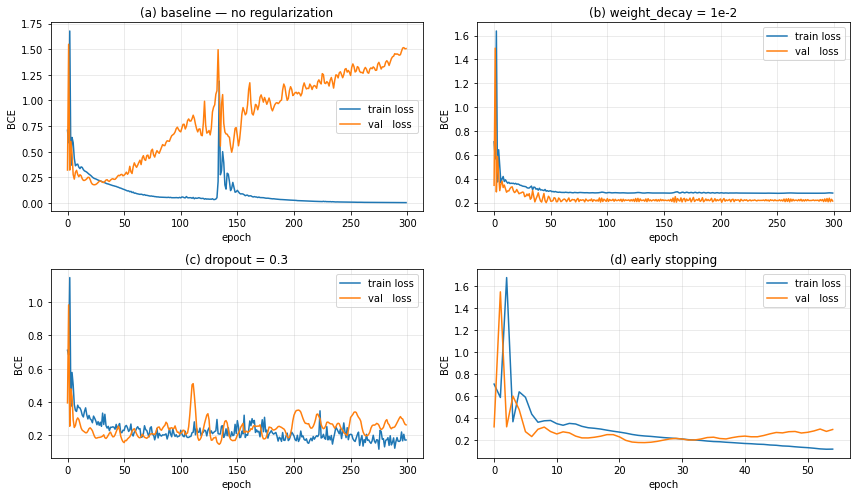

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (name, hist) in zip(axes.ravel(), [
    ("(a) baseline — no regularization", hist_base),
    ("(b) weight_decay = 1e-2",          hist_wd),
    ("(c) dropout = 0.3",                hist_dr),
    ("(d) early stopping",               hist_es),
]):
    ax.plot(hist["train"], label="train loss")
    ax.plot(hist["val"],   label="val   loss")
    ax.set_title(name); ax.set_xlabel("epoch"); ax.set_ylabel("BCE")
    ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

## 5. Test accuracy — the bottom line

In [7]:
rows = [
    ("baseline          ", base),
    ("weight_decay=1e-2 ", wd),
    ("dropout=0.3       ", dr),
    ("early stopping    ", es),
]
for name, m in rows:
    tr_acc = accuracy(m, X_tr, y_tr)
    va_acc = accuracy(m, X_va, y_va)
    te_acc = accuracy(m, X_te, y_te)
    print(f"{name} train={tr_acc:.3f}  val={va_acc:.3f}  test={te_acc:.3f}")

baseline           train=1.000  val=0.850  test=0.775
weight_decay=1e-2  train=0.900  val=0.917  test=0.858
dropout=0.3        train=0.938  val=0.933  test=0.842
early stopping     train=0.900  val=0.917  test=0.858


Observations:
- The baseline typically has the biggest train–val gap.
- L2 / weight decay shrinks weights, reducing variance.
- Dropout trades a bit of train accuracy for a smaller gap.
- Early stopping reaches a decent test accuracy without touching the model class — just the stopping point.

## 6. Weight magnitudes before vs after weight decay
The whole point of weight decay is to shrink weights. Let's verify.

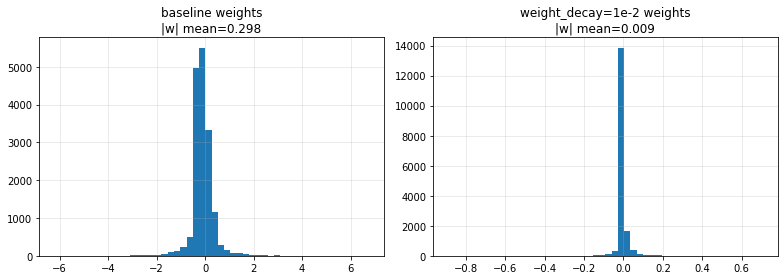

In [8]:
def weight_hist(model, ax, title):
    all_w = torch.cat([p.detach().flatten() for n, p in model.named_parameters() if "weight" in n])
    ax.hist(all_w.numpy(), bins=50)
    ax.set_title(f"{title}\n|w| mean={all_w.abs().mean():.3f}"); ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
weight_hist(base, axes[0], "baseline weights")
weight_hist(wd,   axes[1], "weight_decay=1e-2 weights")
plt.tight_layout(); plt.show()

## 7. Quick checks

In [9]:
# Baseline should have a wider train-val accuracy gap than the regularised models.
base_gap = accuracy(base, X_tr, y_tr) - accuracy(base, X_va, y_va)
wd_gap   = accuracy(wd,   X_tr, y_tr) - accuracy(wd,   X_va, y_va)
dr_gap   = accuracy(dr,   X_tr, y_tr) - accuracy(dr,   X_va, y_va)
print(f"baseline gap = {base_gap:.3f},  weight-decay gap = {wd_gap:.3f},  dropout gap = {dr_gap:.3f}")

assert base_gap >= wd_gap - 0.05, "weight decay should not widen the gap"
# Weight decay must shrink weights
def w_mean(m):
    all_w = torch.cat([p.detach().flatten() for n, p in m.named_parameters() if "weight" in n])
    return all_w.abs().mean().item()
assert w_mean(wd) < w_mean(base), "weight decay must shrink average |w|"
# Early stopping must stop before the full budget
assert stop_epoch < 300, "early stopping should stop before 300 epochs"
print("OK — regularization knobs behave as advertised.")

baseline gap = 0.150,  weight-decay gap = -0.017,  dropout gap = 0.004
OK — regularization knobs behave as advertised.


## Reflection questions

1. Look at plot (a) — at roughly which epoch does val loss start drifting upward? That is your "sweet spot" for early stopping.
2. If you raise dropout to 0.8 on a small network, what goes wrong? Try it and report.
3. Weight decay in Adam is not strictly equivalent to adding `lambda * sum(w^2)` to the loss (this is what `AdamW` fixes). Read up on `torch.optim.AdamW` and explain the difference in one sentence.
4. For a 1 B-parameter LLM pretrained on web text, which of the three remedies here is used, which is not, and why?

## References
- Source theory: [`3-4-regularization.mdx`](../../llm-quest-theory/level-3/3-4-regularization.mdx)
- Next: [`3-5-image-classifier-boss`](3-5-image-classifier-boss.ipynb) — the Level 3 boss.